NOTEBOOK 06 - MODEL COMPARISON
TensorFlow Version : 2.20.0
GPU Available : []
Mounted at /content/drive
GOOGLE DRIVE MOUNTED SUCCESSFULLY
Project Path : /content/drive/MyDrive/Covid_Major_Project
Model Path   : /content/drive/MyDrive/Covid_Major_Project/models
Result Path  : /content/drive/MyDrive/Covid_Major_Project/results
SETUP COMPLETED SUCCESSFULLY
LOADING MOBILENETV2 MODEL
✓ MobileNetV2 Model Loaded Successfully

✓ MobileNetV2 Training History Loaded Successfully
MODEL INFORMATION
Model Name        : MobileNetV2
Input Shape       : (None, 224, 224, 3)
Output Classes    : 4

Total Parameters  : 2619332
TRAINING HISTORY
Best Epoch             : 9
Training Accuracy      : 87.32 %
Validation Accuracy    : 86.33 %
PART 2 COMPLETED SUCCESSFULLY
CREATING MODEL COMPARISON DATAFRAME
MODEL COMPARISON TABLE


,Model,Best Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,MobileNetV2,9,87.32,86.33,0.3456,0.3798


DATAFRAME CREATED SUCCESSFULLY
LOADING CUSTOM CNN RESULTS
✓ Custom CNN History Loaded Successfully
UPDATED MODEL COMPARISON TABLE


,Model,Best Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,MobileNetV2,9,87.32,86.33,0.3456,0.3798
1,Custom CNN,10,86.43,78.17,0.3571,0.5337


PART 4 COMPLETED SUCCESSFULLY
GENERATING MODEL COMPARISON GRAPHS
✓ Comparison CSV Saved
/content/drive/MyDrive/Covid_Major_Project/results/model_comparison_results.csv


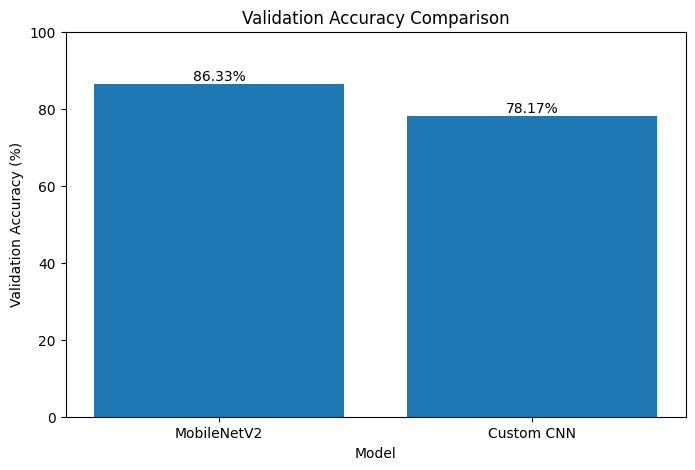

✓ Accuracy Graph Saved
/content/drive/MyDrive/Covid_Major_Project/results/model_accuracy_comparison.png


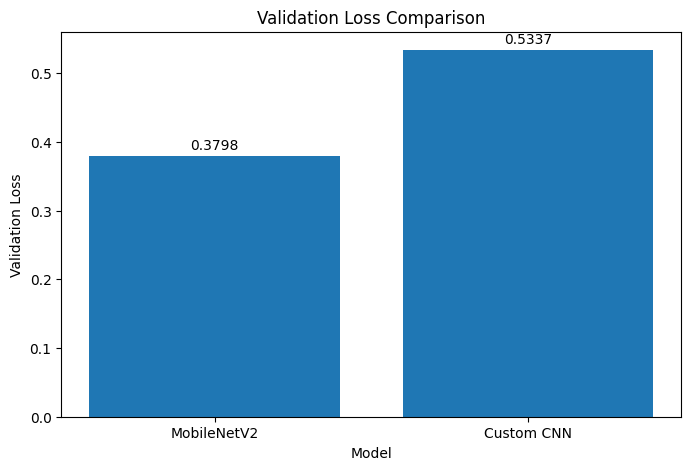

✓ Loss Graph Saved
/content/drive/MyDrive/Covid_Major_Project/results/model_loss_comparison.png
PART 5 COMPLETED SUCCESSFULLY
FINAL MODEL SELECTION
BEST MODEL SELECTED
Model Name            : MobileNetV2
Validation Accuracy   : 86.33 %
Validation Loss       : 0.3798
Best Epoch            : 9
✓ Final Comparison Report Saved
/content/drive/MyDrive/Covid_Major_Project/results/final_model_comparison_report.txt
VERIFYING GENERATED FILES
✓ train.csv
✓ validation.csv
✓ test.csv
✓ custom_cnn_history.csv
✓ model_comparison_results.csv
✓ model_accuracy_comparison.png
✓ model_loss_comparison.png
✓ final_model_comparison_report.txt
✓ mobilenetv2_classification_report.txt
✓ mobilenetv2_confusion_matrix.png
✓ mobilenetv2_evaluation_summary.csv
NOTEBOOK 06 COMPLETED SUCCESSFULLY

PROJECT PROGRESS
----------------------------
✓ Dataset Preparation
✓ CNN Model Training
✓ MobileNetV2 Transfer Learning
✓ Model Comparison
✓ Best Model Selection

NEXT NOTEBOOK
----------------------------
Notebook 07 - Mod

In [ ]:
# ============================================================
# NOTEBOOK 06 - MODEL COMPARISON
# PART 1: IMPORT LIBRARIES AND SETUP
# ============================================================

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import load_model

print("="*60)
print("NOTEBOOK 06 - MODEL COMPARISON")
print("="*60)

print("TensorFlow Version :", tf.__version__)

# Check GPU
gpu = tf.config.list_physical_devices('GPU')

print("GPU Available :", gpu)

print("="*60)


# ============================================================
# GOOGLE DRIVE MOUNT
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

print("="*60)
print("GOOGLE DRIVE MOUNTED SUCCESSFULLY")
print("="*60)


# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT_PATH = "/content/drive/MyDrive/Covid_Major_Project"

MODEL_PATH = PROJECT_PATH + "/models"

RESULT_PATH = PROJECT_PATH + "/results"


# Create results folder if not available

os.makedirs(RESULT_PATH, exist_ok=True)


print("Project Path :", PROJECT_PATH)
print("Model Path   :", MODEL_PATH)
print("Result Path  :", RESULT_PATH)

print("="*60)
print("SETUP COMPLETED SUCCESSFULLY")
print("="*60)

# ============================================================
# NOTEBOOK 06 - MODEL COMPARISON
# PART 2: LOAD MOBILENETV2 MODEL AND HISTORY
# ============================================================

print("="*60)
print("LOADING MOBILENETV2 MODEL")
print("="*60)

# Load MobileNetV2 model

mobilenet_model_path = MODEL_PATH + "/best_mobilenetv2.keras"

mobilenet_model = load_model(mobilenet_model_path)


print("✓ MobileNetV2 Model Loaded Successfully")
print()

# Load training history

history_path = MODEL_PATH + "/history_mobilenetv2.pkl"

with open(history_path, "rb") as file:
    mobilenet_history = pickle.load(file)


print("✓ MobileNetV2 Training History Loaded Successfully")

print("="*60)


# ============================================================
# DISPLAY MODEL INFORMATION
# ============================================================

print("MODEL INFORMATION")
print("="*60)

print("Model Name        : MobileNetV2")
print("Input Shape       :", mobilenet_model.input_shape)
print("Output Classes    :", mobilenet_model.output_shape[-1])

print()

print("Total Parameters  :", mobilenet_model.count_params())

print("="*60)


# ============================================================
# DISPLAY TRAINING RESULTS
# ============================================================

print("TRAINING HISTORY")
print("="*60)

best_epoch = np.argmax(mobilenet_history['val_accuracy']) + 1

best_val_accuracy = max(mobilenet_history['val_accuracy'])

best_train_accuracy = mobilenet_history['accuracy'][best_epoch-1]


print("Best Epoch             :", best_epoch)
print("Training Accuracy      :", round(best_train_accuracy*100,2), "%")
print("Validation Accuracy    :", round(best_val_accuracy*100,2), "%")

print("="*60)

print("PART 2 COMPLETED SUCCESSFULLY")

# ============================================================
# NOTEBOOK 06 - MODEL COMPARISON
# PART 3: CREATE MODEL COMPARISON DATAFRAME
# ============================================================

print("="*60)
print("CREATING MODEL COMPARISON DATAFRAME")
print("="*60)


# ============================================================
# MOBILE NET V2 RESULTS
# ============================================================

mobilenet_best_epoch = np.argmax(
    mobilenet_history['val_accuracy']
) + 1


mobilenet_train_accuracy = (
    mobilenet_history['accuracy'][mobilenet_best_epoch-1]
)

mobilenet_val_accuracy = (
    mobilenet_history['val_accuracy'][mobilenet_best_epoch-1]
)

mobilenet_train_loss = (
    mobilenet_history['loss'][mobilenet_best_epoch-1]
)

mobilenet_val_loss = (
    mobilenet_history['val_loss'][mobilenet_best_epoch-1]
)


# ============================================================
# CREATE DATAFRAME
# ============================================================

comparison_data = {

    "Model": [
        "MobileNetV2"
    ],

    "Best Epoch": [
        mobilenet_best_epoch
    ],

    "Training Accuracy": [
        round(mobilenet_train_accuracy * 100, 2)
    ],

    "Validation Accuracy": [
        round(mobilenet_val_accuracy * 100, 2)
    ],

    "Training Loss": [
        round(mobilenet_train_loss, 4)
    ],

    "Validation Loss": [
        round(mobilenet_val_loss, 4)
    ]

}


comparison_df = pd.DataFrame(comparison_data)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("MODEL COMPARISON TABLE")
print("="*60)

display(comparison_df)


print("="*60)
print("DATAFRAME CREATED SUCCESSFULLY")
print("="*60)

# ============================================================
# NOTEBOOK 06 - MODEL COMPARISON
# PART 4: LOAD CNN MODEL RESULTS AND UPDATE COMPARISON
# ============================================================

print("="*60)
print("LOADING CUSTOM CNN RESULTS")
print("="*60)


# CNN history path

cnn_history_path = MODEL_PATH + "/history_custom.pkl"


# Load CNN history

with open(cnn_history_path, "rb") as file:
    cnn_history = pickle.load(file)


print("✓ Custom CNN History Loaded Successfully")


# Find best epoch

cnn_best_epoch = np.argmax(
    cnn_history['val_accuracy']
) + 1


# Extract metrics

cnn_train_accuracy = cnn_history['accuracy'][cnn_best_epoch-1]

cnn_val_accuracy = cnn_history['val_accuracy'][cnn_best_epoch-1]

cnn_train_loss = cnn_history['loss'][cnn_best_epoch-1]

cnn_val_loss = cnn_history['val_loss'][cnn_best_epoch-1]


# Create CNN dataframe row

cnn_row = pd.DataFrame({

    "Model": ["Custom CNN"],

    "Best Epoch": [
        cnn_best_epoch
    ],

    "Training Accuracy": [
        round(cnn_train_accuracy * 100, 2)
    ],

    "Validation Accuracy": [
        round(cnn_val_accuracy * 100, 2)
    ],

    "Training Loss": [
        round(cnn_train_loss, 4)
    ],

    "Validation Loss": [
        round(cnn_val_loss, 4)
    ]

})


# Add CNN to comparison

comparison_df = pd.concat(
    [comparison_df, cnn_row],
    ignore_index=True
)


print("="*60)
print("UPDATED MODEL COMPARISON TABLE")
print("="*60)

display(comparison_df)


print("="*60)
print("PART 4 COMPLETED SUCCESSFULLY")
print("="*60)

# ============================================================
# NOTEBOOK 06 - MODEL COMPARISON
# PART 5: GENERATE COMPARISON GRAPHS AND SAVE RESULTS
# ============================================================

print("="*60)
print("GENERATING MODEL COMPARISON GRAPHS")
print("="*60)


# ============================================================
# SAVE COMPARISON TABLE
# ============================================================

comparison_csv_path = RESULT_PATH + "/model_comparison_results.csv"

comparison_df.to_csv(
    comparison_csv_path,
    index=False
)

print("✓ Comparison CSV Saved")
print(comparison_csv_path)


# ============================================================
# ACCURACY COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Validation Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy Comparison")

plt.ylim(0,100)

for i, value in enumerate(comparison_df["Validation Accuracy"]):
    plt.text(
        i,
        value + 1,
        str(value) + "%",
        ha="center"
    )

accuracy_graph_path = RESULT_PATH + "/model_accuracy_comparison.png"

plt.savefig(
    accuracy_graph_path,
    bbox_inches="tight"
)

plt.show()

print("✓ Accuracy Graph Saved")
print(accuracy_graph_path)


# ============================================================
# LOSS COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Validation Loss"]
)

plt.xlabel("Model")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")


for i, value in enumerate(comparison_df["Validation Loss"]):
    plt.text(
        i,
        value + 0.01,
        str(value),
        ha="center"
    )


loss_graph_path = RESULT_PATH + "/model_loss_comparison.png"

plt.savefig(
    loss_graph_path,
    bbox_inches="tight"
)

plt.show()


print("✓ Loss Graph Saved")
print(loss_graph_path)


print("="*60)
print("PART 5 COMPLETED SUCCESSFULLY")
print("="*60)

# ============================================================
# NOTEBOOK 06 - MODEL COMPARISON
# PART 6: FINAL MODEL SELECTION AND NOTEBOOK COMPLETION
# ============================================================

print("="*60)
print("FINAL MODEL SELECTION")
print("="*60)


# ============================================================
# SELECT BEST MODEL BASED ON VALIDATION ACCURACY
# ============================================================

best_model_index = comparison_df["Validation Accuracy"].idxmax()

best_model = comparison_df.loc[best_model_index]


print("BEST MODEL SELECTED")
print("="*60)

print("Model Name            :", best_model["Model"])
print("Validation Accuracy   :", best_model["Validation Accuracy"], "%")
print("Validation Loss       :", best_model["Validation Loss"])
print("Best Epoch            :", best_model["Best Epoch"])

print("="*60)


# ============================================================
# SAVE FINAL MODEL REPORT
# ============================================================

report_path = RESULT_PATH + "/final_model_comparison_report.txt"


with open(report_path, "w") as file:

    file.write("="*60 + "\n")
    file.write("COVID-19 X-RAY DETECTION MODEL COMPARISON REPORT\n")
    file.write("="*60 + "\n\n")

    file.write("MODEL PERFORMANCE SUMMARY\n")
    file.write("-"*60 + "\n")

    file.write(
        comparison_df.to_string(index=False)
    )

    file.write("\n\n")

    file.write("BEST MODEL\n")
    file.write("-"*60 + "\n")

    file.write(
        "Selected Model : " + str(best_model["Model"]) + "\n"
    )

    file.write(
        "Validation Accuracy : "
        + str(best_model["Validation Accuracy"])
        + "%\n"
    )

    file.write(
        "Validation Loss : "
        + str(best_model["Validation Loss"])
        + "\n"
    )


print("✓ Final Comparison Report Saved")
print(report_path)


# ============================================================
# VERIFY RESULT FILES
# ============================================================

print("="*60)
print("VERIFYING GENERATED FILES")
print("="*60)


result_files = os.listdir(RESULT_PATH)

for f in result_files:
    print("✓", f)


print("="*60)

print("NOTEBOOK 06 COMPLETED SUCCESSFULLY")
print("="*60)

print()
print("PROJECT PROGRESS")
print("----------------------------")
print("✓ Dataset Preparation")
print("✓ CNN Model Training")
print("✓ MobileNetV2 Transfer Learning")
print("✓ Model Comparison")
print("✓ Best Model Selection")
print()
print("NEXT NOTEBOOK")
print("----------------------------")
print("Notebook 07 - Model Evaluation & Testing")
